In [1]:
library(tidyverse)
library(reshape2)

source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.5.1     ✔ purrr   1.0.2
✔ tibble  3.2.1     ✔ dplyr   1.1.4
✔ tidyr   1.3.1     ✔ stringr 1.5.1
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




---
# Deconvolution - Rivers

In [2]:
suppressMessages(library(grid))
suppressMessages(library(gridExtra))
library(patchwork)

In [3]:
names(master_pal)

ERROR: Error in eval(expr, envir, enclos): object 'master_pal' not found


In [ ]:
### make palette
master_pal = c('platelet'='#0F3B70','myeloid_progenitor'='#666D1C','b_cell'='#F3A27D',
              'endothelial_cell'='#841A2B','nk_cell'='#8FAF7B','monocyte'='#DFB317',
              'erythrocyte_erythroid_progenitor'='#587A63','hematopoietic_stem_cell'='#0093B7',
              'neutrophil'='#B088B7','intestinal_tuft_cell'='#35C1E8','t_cell'='#91C846',
              'melanocyte'='#0482FB','plasma_cell'='#D91586','mature_conventional_dendritic_cell'='#521F2F',
              'thymocyte'='#AEBBE6','innate_lymphoid_cell'='#B9B00D','microglial_cell'='#3CA6F2',
              'schwann_cell'='#DED1A6','smooth_muscle_cell'='#8E104E','plasmablast'='#8F4A00',
              'cell_of_skeletal_muscle'='#02760D','intrahepatic_cholangiocyte'='#FFE036',
              'ciliated_cell_lung_ciliated_cell'='#2E978F',
              'enterocyte_of_epithelium_of_large_intestine_enterocyte_of_epithelium_of_small_intestine_intestinal_crypt_stem_cell_of_large_intestine_large_intestine_goblet_cell_mature_enterocyte_paneth_cell_of_epithelium_of_large_intestine_small_intestine_goblet_cell'='#17FFE1',
              'pericyte_cell'='#6D0EB2','cardiac_muscle_cell'='#FC7FE3','pancreatic_pp_cell'='#FB927F',
              'pancreatic_alpha_cell_pancreatic_beta_cell'='#0C56E5','hepatocyte'='#9390E8','pulmonary_ionocyte'='#FE74A4',
              'kidney_epithelial_cell'='#92158B','macrophage'='#4CFA1A','fibroblast_mesenchymal_stem_cell'='#E50206',
              'salivary_gland_cell'='#C7F0A0',
              'immature_enterocyte_intestinal_crypt_stem_cell_intestinal_crypt_stem_cell_of_small_intestine_transit_amplifying_cell_of_large_intestine'='#025F9A',
              'basophil'='#A012FF','adventitial_cell'='#6F392B','ciliated_epithelial_cell_epithelial_cell_of_uterus'='#AB0928',
              'luminal_cell_of_prostate_epithelium'='#220793','basal_cell'='#CEAA91','pancreatic_ductal_cell'='#ECA6BF',
              'tendon_cell'='#C1747C','pancreatic_stellate_cell'='#55175D','stromal_cell'='#E008D2',
              'basal_cell_of_prostate_epithelium'='#D6AFE5','mast_cell'='#000EF6','mucus_secreting_cell_secretory_cell_tracheal_goblet_cell'='#303D95',
              'club_cell_of_prostate_epithelium_hillock_cell_of_prostate_epithelium_hillock.club_cell_of_prostate_epithelium'='#FEC774',
              'ionocyte_luminal_epithelial_cell_of_mammary_gland'='#F76716','medullary_thymic_epithelial_cell'='#630603',
              'type_ii_pneumocyte'='#183956','mesothelial_cell'='#A3D6EA','acinar_cell_of_salivary_gland_myoepithelial_cell'='#51FEA0',
              'club_cell_type_i_pneumocyte'='#A9DAC9','bladder_urothelial_cell'='#6F7B1E',
              'intestinal_enteroendocrine_cell_paneth_cell_of_epithelium_of_small_intestine_transit_amplifying_cell_of_small_intestine'='#4EA10F',
              'duct_epithelial_cell_serous_cell_of_epithelium_of_bronchus'='#F09601','pancreatic_delta_cell'='#2C8DAF','goblet_cell'='#09585E',
              'respiratory_goblet_cell_respiratory_mucous_cell_serous_cell_of_epithelium_of_trachea'='#06C968','keratinocyte'='#239A56',
              'duodenum_glandular_cell'='#B36A4A','pancreatic_acinar_cell'='#175738','Other'='grey')
              

names(master_pal) = NULL


subset_decon <- function(df_decon, CELLTYPES){
    df_decon <- df_decon %>%                                            
        mutate(celltype = ifelse(celltype %in% CELLTYPES, as.character(celltype), "Other")) %>%
        group_by(sample_id, celltype) %>%
        summarize(fraction = sum(fraction)) %>%
        mutate(celltype = factor(celltype, levels = CELLTYPES))

    return(df_decon)
}



make_riverplot <- function(
                    meta,            # metadata file 
                    decon_mtrx,          # deconvolution matrix
                    N,           # number of top cell types to keep
                    CELLTYPES = NA, # top cell types to keep
                    ORDER = c("PR","D0","E","1M","2M","3M","6M","HD")){
    
    # melt decon matrix
    decon_m <- decon_mtrx %>% melt(.,id.vars = c("sample_id"))%>%            
        rename(celltype = variable, fraction = value)

    

    # get top cell types
    if(is.na(CELLTYPES)){
        CELLTYPES <- decon_m %>% 
            group_by(celltype) %>%
            summarize(fraction = sum(fraction)) %>%
            arrange(desc(fraction)) %>%
            head(N) %>%
            pull(celltype) %>% as.character()
        CELLTYPES = c(CELLTYPES, "Other")
    }

    # subset decon matrix
    decon_m <- subset_decon(decon_m, CELLTYPES)

    # merge with metadata
    meta <- meta %>% 
        select(sample_id, timepoint) %>%
        mutate(timepoint = factor(timepoint, levels = ORDER)) %>% filter(!is.na(timepoint)) %>% 
        left_join(decon_m, by = "sample_id")

    # create summary
    mdf_sum <- meta %>% 
        group_by(timepoint, celltype) %>%
        summarize(mean_fraction = mean(fraction))


    # return(mdf_sum)

    # create plot
    if(length(unique(mdf_sum$timepoint)) > 1){
        p <- mdf_sum %>% 
            ggplot(aes(x=timepoint, y = mean_fraction))+
            geom_area(aes(fill=celltype,group=celltype), colour="black",size = 0.15, alpha = 0.85)+
            river_plot_options
    }


    if(length(unique(mdf_sum$timepoint)) == 1){
        p <- mdf_sum %>% 
            ggplot(aes(x=timepoint, y = mean_fraction))+
            geom_bar(aes(fill=celltype,group=celltype),stat="identity",position="stack", colour="black",size = 0.15, alpha = 0.85)+
            theme_minimal()+
            river_plot_options
            
    }

    return(list("plot" = p, "data" = mdf_sum, "celltypes" = CELLTYPES))
}



In [ ]:
### DFCI

N_CELLS = 9
YMAX = 0.7

## load metadata
mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% filter(ORIGIN == "DFCI")

### factor timepoint
mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>% 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% 
    unique()

haplo = read.csv("../../cfRNA_data/cleaned_clinical_data/baseline_data.csv") %>% select(Record_ID, hct_hla) %>% 
    mutate(haplo = ifelse(hct_hla == "Haploidentical","Haploidentical","Not-Haploidentical"))

mdf = merge(mdf, haplo, by="Record_ID", all.x=TRUE)

mdf$timepoint <- droplevels(mdf$timepoint)
mdf$timepoint_sym <- droplevels(mdf$timepoint_sym)

mdf$timepoint = mdf$timepoint_sym

## load decon
decon = read.delim("../1_DATA/decon_passQC.tsv")

### Remove platelet and rescale
decon = decon %>% column_to_rownames("sample_id") #%>% select(-platelet) #%>% select(-megakaryocyte) %>% select(-erythrocyte)
decon <- t(apply(decon, 1, function(x) x / sum(x)))
decon <- decon %>% data.frame() %>% rownames_to_column("sample_id")


##################################################
## Change decon names
colnames(decon)[2:ncol(decon)] = str_to_title(gsub("_"," ",colnames(decon)[2:ncol(decon)]))

##################################################

master_pal[N_CELLS+1] = "grey"
river_plot_options <- list(
            theme_cfrna_print(),
            labs(y = "Mean Fraction"),
            theme(strip.text = element_text(size = 12),
                strip.background = element_rect(fill="#FFFFFF",color="black"),
                axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
                axis.text = element_text(size = 6),
                axis.title.x = element_blank(),
                axis.title.y = element_text(size = 6),
                title = element_blank()) ,
            theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank()),
            scale_fill_manual(values = master_pal)
)


## make river plots
EVENTS_dfci = c("Pre-Conditioning","Day of Infusion","Engraftment","1 Month","2 Month","3 Month","6 Month")

EVENTS_dfci = c("Pre-Conditioning","Day of Infusion","Engraftment","1 Month","2 Month","3 Month","6 Month")
mdf_dfci = make_riverplot(mdf, 
                            decon, 
                            N = N_CELLS, 
                            ORDER = EVENTS_dfci)

EVENTS_hd = c("Healthy Donor")
mdf_hd = make_riverplot(mdf, 
                        decon, 
                        N = N_CELLS, 
                        CELLTYPES = mdf_dfci_H$celltypes, 
                        ORDER = EVENTS_hd)



p2 = mdf_dfci$plot + 
    coord_cartesian(expand = FALSE, ylim = c(0,YMAX)) +
    theme(axis.title.y = element_blank(), axis.text.y = element_blank(), axis.ticks.y = element_blank(),plot.margin = unit(c(5.5,5.5,5.5,0), unit="pt"))


p3 = mdf_hd$plot + 
    theme(plot.margin = unit(c(5.5,5.5,5.5,5.5), unit="pt")) + 
    labs(y = "Mean Fraction") + 
    theme(axis.title.y = element_text(size = 8))+ 
    coord_cartesian(expand = FALSE, ylim = c(0,YMAX))



final_plt <- p3 + p1 + p2 + patchwork::plot_layout(widths = c(1, 8,8))

WIDTH = 4.5
HEIGHT= 2
ggsave("./figures/RIVER_All.pdf",final_plt,width=WIDTH, height = HEIGHT, units = "in")
ggsave("./figures/RIVER_All.png",final_plt,width=WIDTH, height = HEIGHT, units = "in")


`summarise()` has grouped output by 'sample_id'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'timepoint'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'sample_id'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'timepoint'. You can override using the
`.groups` argument.
Warning message in if (is.na(CELLTYPES)) {:
“the condition has length > 1 and only the first element will be used”
`summarise()` has grouped output by 'sample_id'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'timepoint'. You can override using the
`.groups` argument.


In [37]:
library(cowplot)
library(gridExtra)

### Create shared legend
EVENTS = c("HD")
legend_plot = p1 + 
      theme(
        legend.position = "right",                                  # Keep legend on the right for extraction
        legend.box = "horizontal",                                  # Arrange legend items horizontally
        legend.title = element_blank(),                             # Remove legend title
        legend.text = element_text(size = 6),                       # Scale legend text
        legend.key.size = unit(0.4, "cm"),                          # Adjust legend key size
        legend.spacing.x = unit(10, "cm"),                         # Adjust spacing between legend items
        legend.spacing.y = unit(1, "cm")                            # Adjust vertical spacing
  ) +
    guides(fill = guide_legend(nrow = 2),keywidth = unit(1, "cm"), keyheight = unit(0.4, "cm"))


# legend_plot
legend <- cowplot::get_legend(legend_plot)

leg_plt = plot_grid(legend)

### Save
WIDTH= 4.7
HEIGHT= .7
pdf(file="figures/RIVER_All.LEGEND.pdf",
        width=WIDTH,height=HEIGHT, paper="special", bg="white",
        fonts="Helvetica", colormodel = "srgb", pointsize=6, useDingbats = FALSE)

print(leg_plt)

dev.off()

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


png 
  2

---
# CTO & Cell counts - violin

In [68]:
library(ggExtra)
library(ggforce)


## load data
mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% filter(ORIGIN == "DFCI")
metrics = read.delim("../1_DATA/metrics_passQC.tsv")


### factor timepoint
mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>% 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% 
    unique()

mdf$timepoint <- droplevels(mdf$timepoint)
mdf$timepoint_sym <- droplevels(mdf$timepoint_sym)

mdf = mdf %>% mutate(sample_group = factor(sample_group, levels = c("HD", "REF", "COMP"))) 


## Combine with metrics and melt for plotting
mdf_met = merge(mdf, metrics) 

mdf_met = mdf_met %>% 
    select(sample_id, timepoint_sym, HD, sample_group, neutrophil_CBC, neutrophil_decon, monocyte_CBC, monocyte_decon, lymphocyte_CBC, lymphocyte_decon) %>%
    reshape2::melt(.,id.vars = c("sample_id", "timepoint_sym","HD","sample_group")) %>% 
    mutate(measurement= gsub(".*_","",variable)) %>%
    mutate(measurement2 = ifelse(measurement == "decon","CTO Fraction","CBC")) %>%
    mutate(celltype = gsub("_.*","",variable)) 


In [69]:
library(ggpubr)

In [70]:
CTS = c("neutrophil","monocyte","lymphocyte")



WIDTH = 2.3
HEIGHT = 2.75

for (CT in CTS){

    REMOVE_IDS = mdf_met %>% 
        filter(celltype == CT) %>% 
        filter(is.na(value)) %>% 
        pull(sample_id)

    viol_plt = mdf_met %>% 
        filter(celltype == CT) %>% 
        filter(!sample_id %in% REMOVE_IDS) %>% 
        mutate(HD = factor(HD, levels = c(1,0))) %>%
        ggplot(aes(x=timepoint_sym, y=value, color = sample_group, fill = sample_group))+
            geom_split_violin(scale ="width",width = 0.7, alpha = 0.5, size = 0.1)+
            geom_point(size = 0.75, alpha = 0.75, stroke=NA,
              position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.3, 
                                                # dodge.width = 0.8, 
                                                seed=42))+
            theme_cfrna_print()+
            facet_grid(measurement2~HD, scales = "free", space = "free_x")+
            theme(
                axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
                plot.title = element_text(size = 8, hjust = 0.5, vjust = -2),
                axis.title = element_blank(),

                panel.grid.minor = element_blank(),
                panel.background = element_rect(
                    fill = "transparent", 
                    color = "transparent",
                ),
                plot.background = element_rect(
                    fill = "transparent", 
                    color = "transparent",
                ))+    
            labs(title = str_to_title(CT))+
            scale_color_manual(values = COLORs)+
            scale_fill_manual(values = COLORs)

    # viol_plt + stat_compare_means(
    #     aes(group = sample_group,method = "wilcox.test", label = after_stat(p.signif)),
    #     symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
    #     size = 3,
    #     vjust = .75,
    #     hide.ns = TRUE,
    #     )


    ggsave(paste0("./figures/VIOLIN_",CT,".pdf"),width=WIDTH, height = HEIGHT, units = "in")

}


## CTO x Cell counts - scatter

In [71]:
library(ggExtra)

## load data
mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% 
    filter(ORIGIN == "DFCI") %>% 
    filter(timepoint %in% c("1M","2M","3M","6M"))
    
metrics = read.delim("../1_DATA/metrics_passQC.tsv") #%>% select(!SCALE_qubit)

metrics %>% head

mdf_metrics = merge(mdf, metrics, by="sample_id")

WIDTH = 2.23
HEIGHT = 2.23


#save for SBIR
# merge(mdf, metrics, by="sample_id") %>% write.csv("/workdir/cjl332/SBIR/prepr_202504/CTO_Ccounts.csv",row.names=FALSE)



,sample_id,avgDist_trajectory,avgCorrelation_trajectory,Alphatorquevirus_CPM,Pegivirus_CPM,neutrophil_activity,lymphocyte_activity,leukocyte_activity,platelet_activity,rbc_activity,⋯,leukocyte_decon,platelet_decon,rbc_decon,monocyte_decon,basophil_decon,G2M_Z,S_Z,repHistone_CPM,nonrepHistone_CPM,simpson
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,gvhd_hct_cfrna_1_bp51x51,7317.7762,0.7091170,65.14921109,573.221780,NA,NA,NA,NA,NA,⋯,0.47766298,0.2344515,6.469928e-20,9.782251e-02,1.516021e-02,-14.562131,-9.889029,3871.170,1114.2552,0.8672247
2,gvhd_hct_cfrna_100_bp61x61,4748.5156,0.7008951,2.56115026,18965.264346,8.790327e-12,NA,2.226165e-11,4.625563e-12,5.369907e-11,⋯,0.12803723,0.4356516,2.697368e-01,4.818883e-11,9.582075e-20,43.441906,12.635144,13856.848,1752.7141,0.7270753
3,gvhd_hct_cfrna_101_bp61x61,3344.0707,0.8419018,0.04109682,3.205552,1.789312e-29,2.687647e-10,4.169087e-11,2.231453e-12,9.498995e-12,⋯,0.31375151,0.4970777,5.075524e-02,1.523002e-03,4.257471e-13,-21.821676,-13.964383,8546.592,1146.8045,0.7037618
4,gvhd_hct_cfrna_102_bp61x61,215.8516,0.8322982,0.05291032,7.301624,7.381090e-30,1.080800e-10,4.543020e-12,1.224659e-12,1.483801e-12,⋯,0.05970131,0.7887254,2.154293e-02,9.227564e-20,9.603542e-20,-20.942436,-22.358244,5338.243,961.8293,0.3706861
5,gvhd_hct_cfrna_103_bp61x61,6138.8280,0.7996557,2.66602218,1719.621335,8.362180e-12,6.293927e-11,2.001256e-11,2.567047e-12,8.939903e-12,⋯,0.22435185,0.4849713,4.429493e-02,5.555999e-04,9.348307e-20,-8.295307,-6.887041,6800.758,1138.6577,0.7257493
6,gvhd_hct_cfrna_104_bp61x61,9694.5298,0.7942089,0.00000000,1.161814,1.321168e-28,5.808823e-12,4.764964e-12,1.051286e-12,1.053788e-11,⋯,0.02972664,0.6929075,1.069692e-01,6.851716e-20,7.234405e-20,9.129105,-21.014624,9267.498,1163.2612,0.4955365


In [72]:
## NEUTROPHILS
VAR1 = "neutrophil_decon"
VAR2 = "neutrophil_CBC"

t = mdf_metrics %>% 
    filter(!is.na(.data[[VAR1]]) & !is.na(.data[[VAR2]])) %>% 
    filter(.data[[VAR2]] > 0)
t1 = t %>% pull(VAR1) %>% log10()
t2 = t %>% pull(VAR2) %>% log10()
wilcox.test(t1,t2)
cor.test(t1,t2)
cat("===========================\n")

## Monocytes
VAR1 = "monocyte_decon"
VAR2 = "monocyte_CBC"

t = mdf_metrics %>% 
    filter(!is.na(.data[[VAR1]]) & !is.na(.data[[VAR2]])) %>% 
    filter(.data[[VAR2]] > 0)
t1 = t %>% pull(VAR1) %>% log10()
t2 = t %>% pull(VAR2) %>% log10()
wilcox.test(t1,t2)
cor.test(t1,t2)
cat("===========================\n")

## Lymphocytes
VAR1 = "lymphocyte_decon"
VAR2 = "lymphocyte_CBC"

t = mdf_metrics %>% 
    filter(!is.na(.data[[VAR1]]) & !is.na(.data[[VAR2]])) %>% 
    filter(.data[[VAR2]] > 0)
t1 = t %>% pull(VAR1) %>% log10()
t2 = t %>% pull(VAR2) %>% log10()
wilcox.test(t1,t2)
cor.test(t1,t2)


## Lymphocytes
VAR1 = "lymphocyte_decon"
VAR2 = "lymphocyte_CBC"

t = mdf_metrics %>% 
    filter(sample_id != "hct_cfrna_455_bp61x61") %>% 
    filter(!is.na(.data[[VAR1]]) & !is.na(.data[[VAR2]])) %>% 
    filter(.data[[VAR2]] > 0)
t1 = t %>% pull(VAR1) %>% log10()
t2 = t %>% pull(VAR2) %>% log10()
wilcox.test(t1,t2)
cor.test(t1,t2)


	Wilcoxon rank sum test with continuity correction

data:  t1 and t2
W = 309, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Pearson's product-moment correlation

data:  t1 and t2
t = 1.0027, df = 296, p-value = 0.3168
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.05580523  0.17067687
sample estimates:
       cor 
0.05818445 



	Wilcoxon rank sum test with continuity correction

data:  t1 and t2
W = 2677, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Pearson's product-moment correlation

data:  t1 and t2
t = 0.87671, df = 295, p-value = 0.3814
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.06320098  0.16383944
sample estimates:
       cor 
0.05097786 



	Wilcoxon rank sum test with continuity correction

data:  t1 and t2
W = 10503, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Pearson's product-moment correlation

data:  t1 and t2
t = 1.9254, df = 294, p-value = 0.05514
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.00244384  0.22276232
sample estimates:
      cor 
0.1115918 



	Wilcoxon rank sum test with continuity correction

data:  t1 and t2
W = 10503, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Pearson's product-moment correlation

data:  t1 and t2
t = 4.2515, df = 293, p-value = 2.858e-05
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1304444 0.3457322
sample estimates:
      cor 
0.2410515 


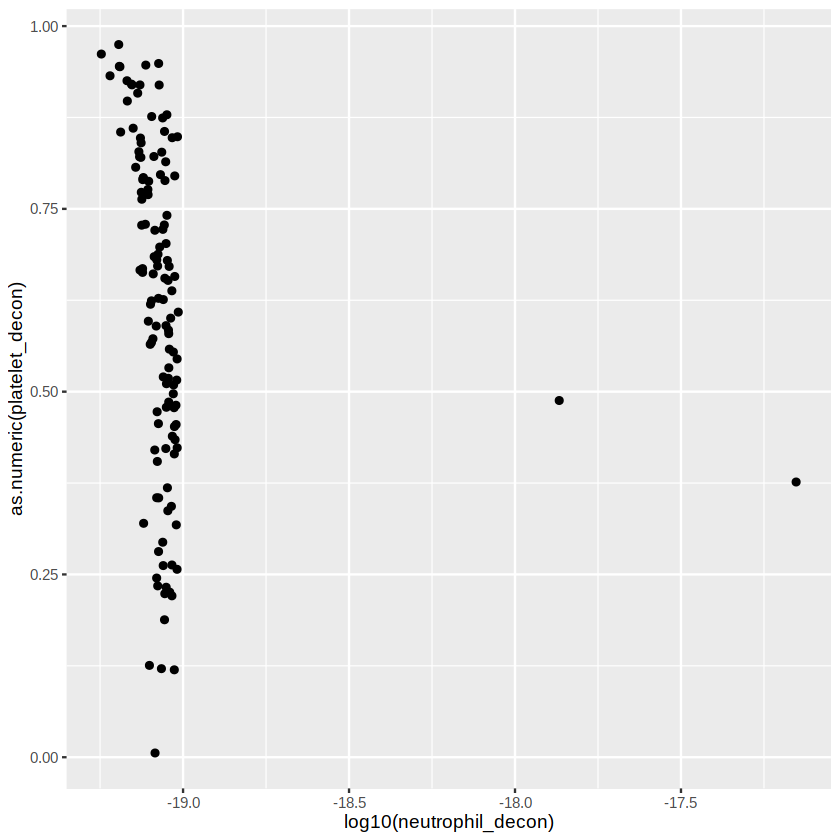

In [73]:
merge(mdf, metrics, by="sample_id") %>% 
    filter(log10(neutrophil_decon) < -17) %>%
    ggplot(aes(x=log10(neutrophil_decon),y=as.numeric(platelet_decon))) + 
    geom_point()

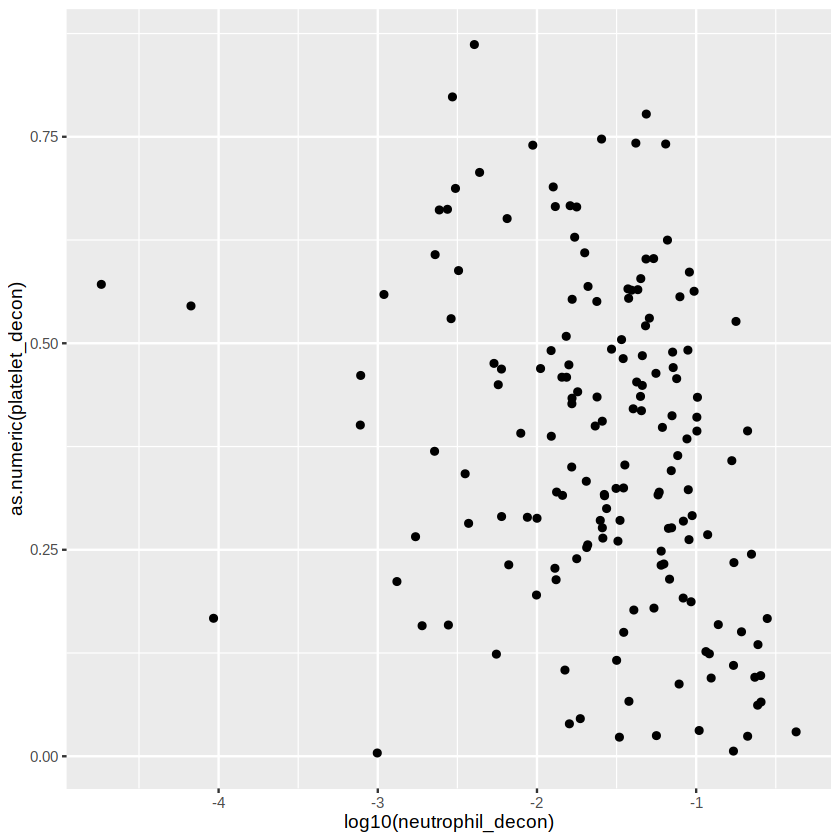

In [75]:
merge(mdf, metrics, by="sample_id") %>% 
    filter(log10(neutrophil_decon) > -5) %>%
    ggplot(aes(x=log10(neutrophil_decon),y=as.numeric(platelet_decon))) + 
    geom_point()

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


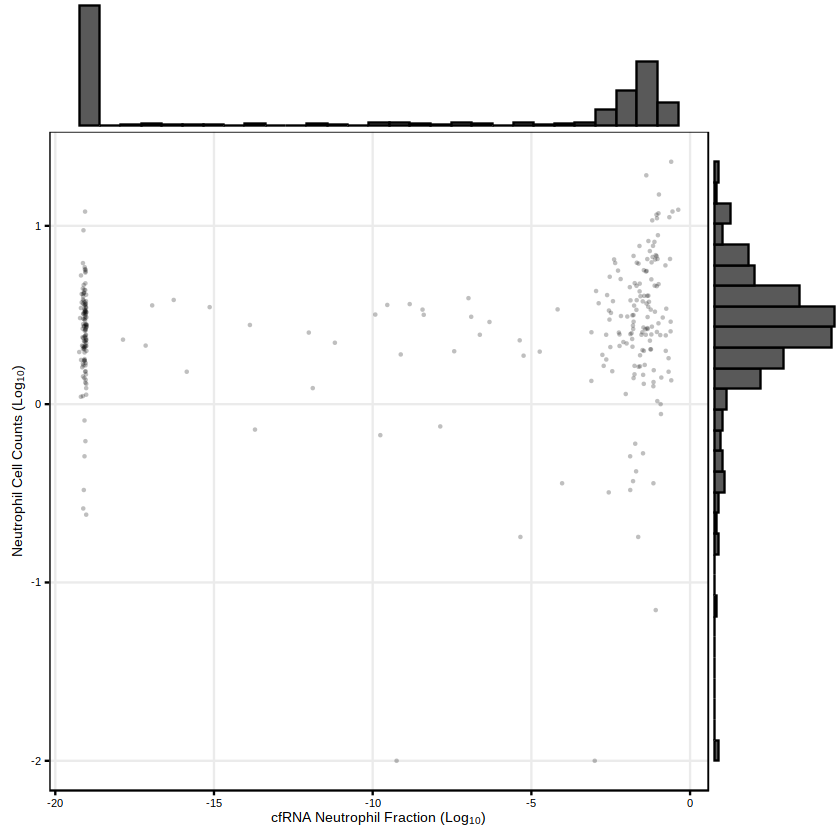

In [21]:
## NEUTROPHIL

plt <- merge(mdf, metrics, by="sample_id") %>% 
    filter(neutrophil_CBC != 0) %>%
    ggplot(aes(x= log10(neutrophil_decon), y=log10(neutrophil_CBC)))+
    geom_point(size = 1, alpha = 0.25, stroke=NA)+
    theme_cfrna_print()+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    theme(panel.grid.minor = element_blank()) +
    theme(
        panel.background = element_rect(
            fill = "white", 
            color = "white",
        ),
        plot.background = element_rect(
            fill = "transparent", 
            color = "transparent",
        )
      )+
    labs(x = bquote("cfRNA Neutrophil Fraction ("*Log[10]*")"), y= bquote("Neutrophil Cell Counts ("*Log[10]*")"))

plt_neutro <- ggMarginal(plt, 
                        type = "histogram",
                        xparams = list(bins = 30), 
                        # groupColour = TRUE,
                        # groupFill = TRUE
                        )#

ggsave("./figures/Marg_neutro.pdf",plt_neutro, width=WIDTH, height = HEIGHT, units = "in", bg = "transparent")
plt_neutro

In [22]:
merge(mdf, metrics, by="sample_id") %>% 
    filter(log10(monocyte_decon) > -7 & log10(monocyte_decon) < -5) %>% 
    select(sample_id, timepoint, monocyte_decon, monocyte_CBC) 

sample_id,timepoint,monocyte_decon,monocyte_CBC
<chr>,<chr>,<dbl>,<dbl>
gvhd_hct_cfrna_172_bp61x61,2M,9.289357e-07,0.00
gvhd_hct_cfrna_18_bp51x51,3M,1.264142e-07,0.35
gvhd_hct_cfrna_187_bp61x61,3M,3.350408e-06,NA
gvhd_hct_cfrna_43_bp51x51,2M,7.795705e-06,NA
gvhd_hct_cfrna_486_bp61x61,6M,1.560049e-07,0.60
gvhd_hct_cfrna_89_bp61x61,6M,9.179938e-06,0.24
hct_cfrna_322_bp61x61,2M,5.302988e-07,0.40


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


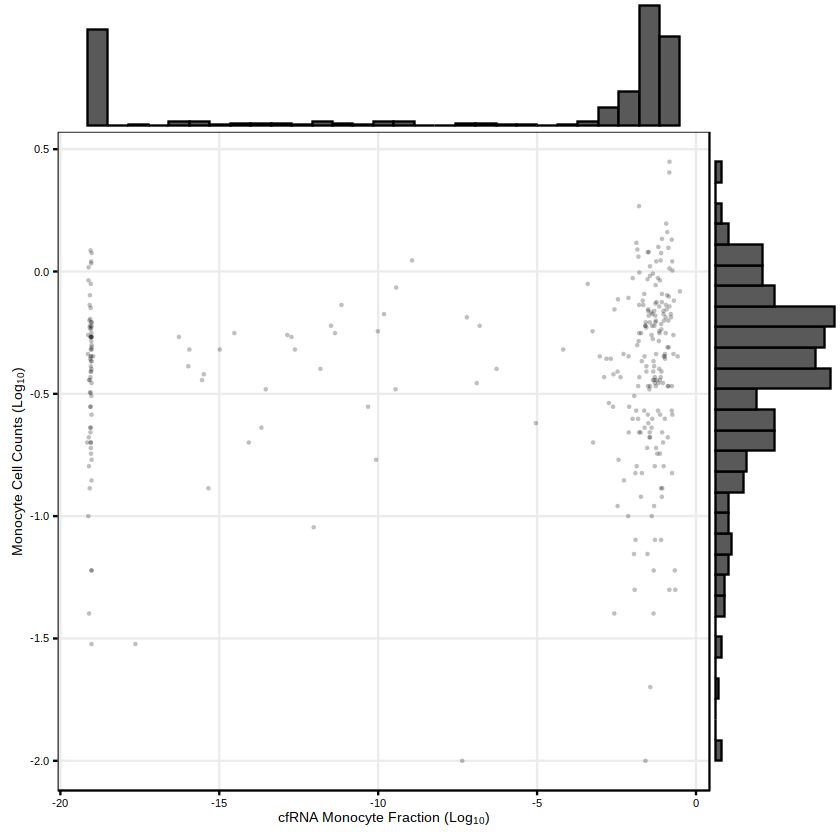

In [23]:
## MONOCYTE

plt_mono <- merge(mdf, metrics, by="sample_id") %>% 
    filter(monocyte_CBC != 0) %>%
    ggplot(aes(x= log10(monocyte_decon), y=log10(monocyte_CBC)))+
    geom_point(size = 1, alpha = 0.25, stroke=NA)+
    theme_cfrna_print()+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    theme(panel.grid.minor = element_blank(),) +
    theme(
        panel.background = element_rect(
            fill = "white", 
            color = "white",
        ),
        plot.background = element_rect(
            fill = "transparent", 
            color = "transparent",
        )
      )+
    labs(x = bquote("cfRNA Monocyte Fraction ("*Log[10]*")"), y= bquote("Monocyte Cell Counts ("*Log[10]*")"))

plt_mono_marginal <- ggMarginal(plt_mono, type = "histogram", xparams = list(bins = 30))

ggsave("./figures/Marg_monocyte.pdf", plt_mono_marginal, width=WIDTH, height = HEIGHT, units = "in", bg = "transparent")
plt_mono_marginal

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


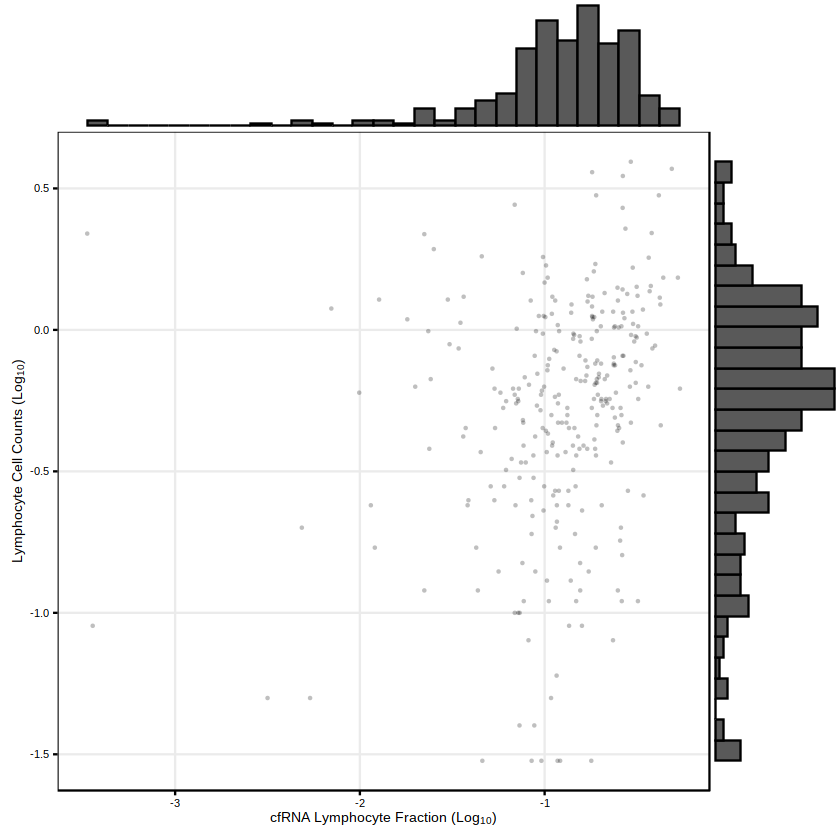

In [47]:
## LYMPHOCYTE

## LYMPHOCYTE
plt_lympho <- merge(mdf, metrics, by="sample_id") %>%  
    filter(sample_id != "hct_cfrna_455_bp61x61") %>% 
    filter(lymphocyte_CBC != 0) %>%
    ggplot(aes(x= log10(lymphocyte_decon), y=log10(lymphocyte_CBC)))+
    geom_point(size = 1, alpha = 0.25, stroke=NA)+
    theme_cfrna_print()+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    theme(panel.grid.minor = element_blank(),) +
    theme(
        panel.background = element_rect(
            fill = "white", 
            color = "white",
        ),
        plot.background = element_rect(
            fill = "transparent", 
            color = "transparent",
        )
      )+
    labs(x = bquote("cfRNA Lymphocyte Fraction ("*Log[10]*")"), y= bquote("Lymphocyte Cell Counts ("*Log[10]*")"))

plt_lympho_marginal <- ggMarginal(plt_lympho, type = "histogram", xparams = list(bins = 30))

ggsave("./figures/Marg_lymphocyte.pdf", plt_lympho_marginal, width=WIDTH, height = HEIGHT, units = "in", bg = "transparent")
plt_lympho_marginal

In [30]:
merge(mdf, metrics, by="sample_id") %>%  arrange(lymphocyte_decon) %>% select(sample_id, timepoint, lymphocyte_decon, lymphocyte_CBC, platelet_decon) %>% head(10) 

,sample_id,timepoint,lymphocyte_decon,lymphocyte_CBC,platelet_decon
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,hct_cfrna_455_bp61x61,6M,6.894171e-11,1.06,0.005793393
2,hct_cfrna_347_bp61x61,6M,3.343331e-04,2.19,0.031173751
3,gvhd_hct_cfrna_205_bp61x61,1M,3.579646e-04,0.09,0.974755562
4,gvhd_hct_cfrna_160_bp61x61,1M,3.164266e-03,0.05,0.919552469
5,gvhd_hct_cfrna_151_bp61x61,2M,4.850952e-03,0.20,0.860358992
6,gvhd_hct_cfrna_94_bp61x61,1M,5.375900e-03,0.05,0.559054506
7,gvhd_hct_cfrna_82_bp61x61,6M,6.926810e-03,NA,0.878713940
8,hct_cfrna_404_bp61x61,1M,7.005592e-03,1.19,0.741228192
9,gvhd_hct_cfrna_224_bp61x61,2M,9.919634e-03,0.60,0.948865224


In [41]:
mdf %>% filter(sample_id == "hct_cfrna_455_bp61x61") %>% t()

Record_ID,56
sample_id,hct_cfrna_455_bp61x61
date,2019-05-29
timepoint,6M
SCALE_qubit,3.592173e-09
sample_group,COMP
all_comps,_relapse_agvhd
transplant_date,2018-12-12
date_taper_start,NA
date_taper_end,NA
date_agvhd,2019-02-27


In [44]:
read.csv("../../cfRNA_data/cleaned_clinical_data/baseline_data.csv") %>% 
    filter(Record_ID == 56) %>% 
    t()

X,44
Record_ID,56
group,control
date_consent,2018-12-07
age,65
sex,Male
race,Caucasian
ethnicity,Non-latino
reason_hct,acute myeloid leukemia
baseline_disease,AML
hct_date,2018-12-12


In [43]:
read.csv("../../cfRNA_data/cleaned_clinical_data/complication-dates.csv") %>% 
    filter(Record_ID == 56) %>% 
    t()

Record_ID,56
BKVR,NA
BKVD,NA
BKVR_date,NA
BKVD_date,NA
aGVHD,TRUE
aGVHD_date,2019-02-27
aGVHD_max_grade,2
cGVHD,FALSE
cGVHD_date,NA
cGVHD_max_severity,


In [38]:
read.delim("../1_DATA/decon_passQC.tsv") %>% 
    filter(sample_id == "hct_cfrna_455_bp61x61") %>% column_to_rownames("sample_id") %>% t() %>% data.frame() %>% 
     arrange(desc(hct_cfrna_455_bp61x61)) %>% 
    head

,hct_cfrna_455_bp61x61
,<dbl>
hematopoietic_stem_cell,0.652148858
myeloid_progenitor,0.316531629
basophil,0.012212177
platelet,0.005793393
immature_enterocyte_intestinal_crypt_stem_cell_intestinal_crypt_stem_cell_of_small_intestine_transit_amplifying_cell_of_large_intestine,0.004952795
endothelial_cell,0.004064086


---
# Viral

In [10]:
library(ggExtra)

## load data
mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% filter(ORIGIN == "DFCI")

### factor timepoint
mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>% 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% filter(!is.na(timepoint_sym)) %>%
    mutate(HD = factor(HD, levels = c(1,0))) %>% filter(!is.na(HD)) %>%
    unique()

mdf$timepoint <- droplevels(mdf$timepoint)
mdf$timepoint_sym <- droplevels(mdf$timepoint_sym)


## add metrics
metrics = read.delim("../1_DATA/metrics_passQC.tsv")
mdf_met = merge(mdf, metrics) %>% unique()


WIDTH = 2.5
HEIGHT = 2.25

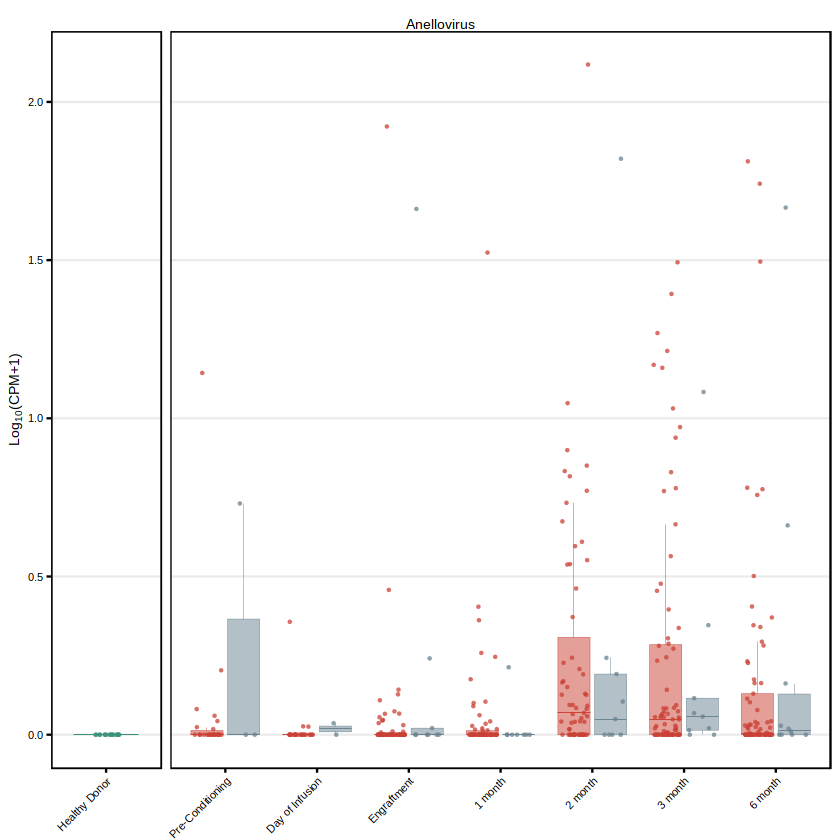

In [11]:
plt = mdf_met %>% 
    ggplot(aes(x=timepoint_sym, y=log10(Alphatorquevirus_CPM+1), color = sample_group, fill = sample_group))+
    geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.5, size = 0.1) +
    geom_point(size = 1, alpha = 0.75, stroke=NA,
              position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.3, 
                                                seed=42)
                )+
    theme_cfrna_print()+
    facet_grid(~HD, scales = "free_x", space = "free")+
    theme(
                axis.title.x = element_blank(),
                axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
                plot.title = element_text(size = 8, hjust = 0.5, vjust = -2.5),
            )+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    theme(panel.grid.minor = element_blank(), panel.grid.major.x = element_blank())+
    labs(y= bquote(Log[10]*"(CPM+1)"), title = "Anellovirus")


ggsave("./figures/VIRAL_Alphatorquevirus_CPM.pdf",plt, width=WIDTH, height = HEIGHT, units = "in")
plt

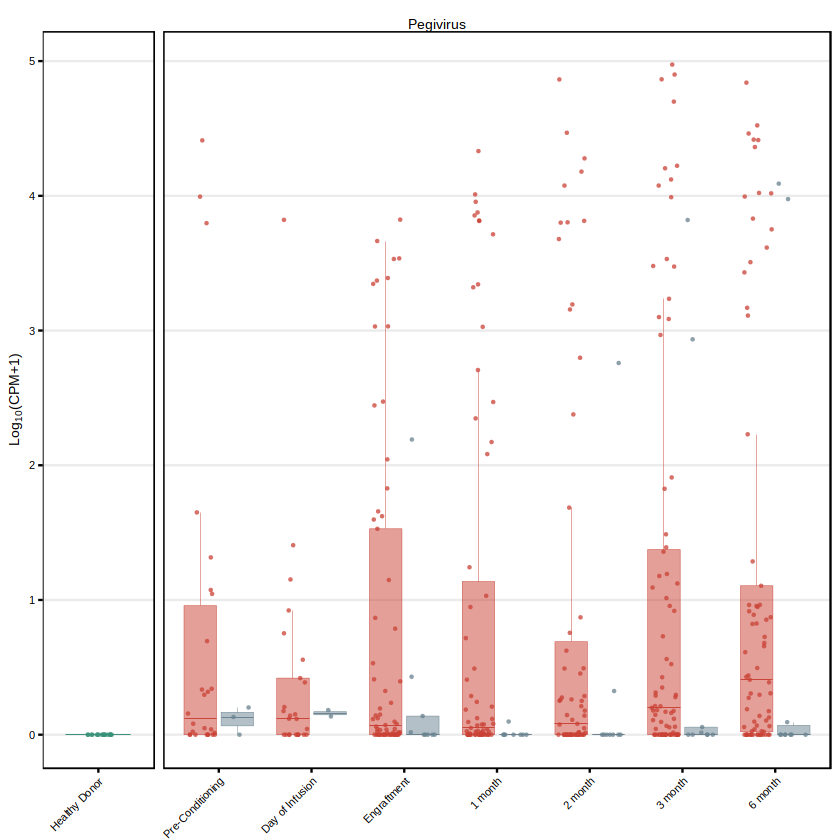

In [12]:
plt = mdf_met %>% 
    ggplot(aes(x=timepoint_sym, y=log10(Pegivirus_CPM+1), color = sample_group, fill = sample_group))+
    geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.5, size = 0.1) +
    geom_point(size = 1, alpha = 0.75, stroke=NA,
              position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.3, 
                                                seed=42)
                )+
    theme_cfrna_print()+
    facet_grid(~HD, scales = "free_x", space = "free")+
    theme(
                axis.title.x = element_blank(),
                axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
                plot.title = element_text(size = 8, hjust = 0.5, vjust = -2.5),
                legend.position = "none",
                strip.background = element_blank(),
                strip.text = element_blank()
            )+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    theme(panel.grid.minor = element_blank(), panel.grid.major.x = element_blank())+
    labs(y= bquote(Log[10]*"(CPM+1)"), title = "Pegivirus")

ggsave("./figures/VIRAL_Pegivirus_CPM.pdf",plt, width=WIDTH, height = HEIGHT, units = "in")
plt

### Other viruses

In [58]:
source("../functions.R")

In [59]:
recipients <- mdf_met %>% pull(sample_id)

## get kingdom counts for each sample
KING_VAR = "Viruses"
king_cts_donor = lapply(recipients, get_superkingdom_counts, SUPKING=KING_VAR) %>% do.call(rbind,.) %>% data.frame()

In [61]:
king_cts_donor %>% filter(genus == "Betacoronavirus") %>% arrange(desc(new_est_reads)) %>% head

,taxonomy_id,kraken_assigned_reads,added_reads,new_est_reads,fraction_total_reads,superkingdom,phylum,class,order,family,genus,species,sample_id
,<int>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,694003,1,0,1,0,Viruses,Pisuviricota,Pisoniviricetes,Nidovirales,Coronaviridae,Betacoronavirus,Betacoronavirus 1,gvhd_hct_cfrna_131_bp61x61
2,1335626,1,0,1,0,Viruses,Pisuviricota,Pisoniviricetes,Nidovirales,Coronaviridae,Betacoronavirus,Middle East respiratory syndrome-related coronavirus,gvhd_hct_cfrna_209_bp61x61
3,694009,1,0,1,0,Viruses,Pisuviricota,Pisoniviricetes,Nidovirales,Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coronavirus,gvhd_hct_cfrna_463_bp61x61
4,694009,1,0,1,0,Viruses,Pisuviricota,Pisoniviricetes,Nidovirales,Coronaviridae,Betacoronavirus,Severe acute respiratory syndrome-related coronavirus,gvhd_hct_cfrna_476_bp61x61
5,290028,1,0,1,0,Viruses,Pisuviricota,Pisoniviricetes,Nidovirales,Coronaviridae,Betacoronavirus,Human coronavirus HKU1,hct_cfrna_294_bp61x61
6,290028,1,0,1,0,Viruses,Pisuviricota,Pisoniviricetes,Nidovirales,Coronaviridae,Betacoronavirus,Human coronavirus HKU1,hct_cfrna_308_bp61x61


`summarise()` has grouped output by 'sample_id'. You can override using the
`.groups` argument.


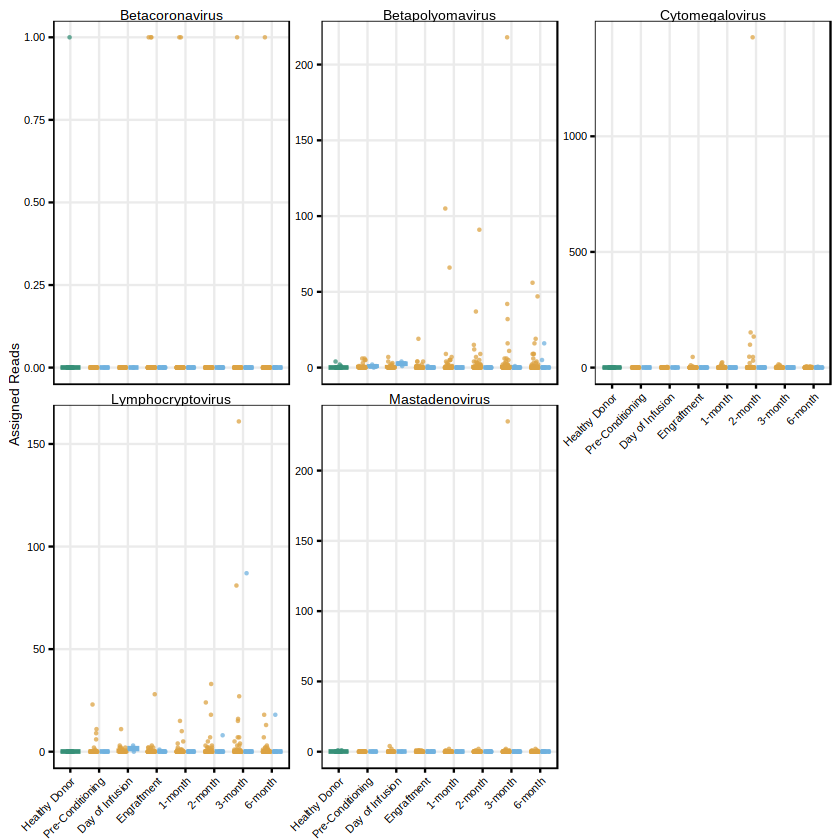

In [63]:
## CMV - genus=Cytomegalovirus
## BKV - genus=Betapolyomavirus
## EBV - genus=Lymphocryptovirus
## adenovirus - genus=Mastadenovirus
## corona - genus=Betacoronavirus

genuses = c("Cytomegalovirus", "Betapolyomavirus", "Lymphocryptovirus","Mastadenovirus", "Betacoronavirus")

geni_df <- king_cts_donor %>% 
    filter(genus %in% all_of(genuses)) %>% 
    group_by(sample_id, genus) %>% summarize(sum_cnts = sum(new_est_reads))

### add missing samples
all_samps = recipients


for(GENI in genuses){

    zero_df <- data.frame(sample_id = setdiff(all_samps, geni_df %>% filter(genus == GENI) %>% pull(sample_id)),
                            genus = GENI,
                            sum_cnts = 0)

    geni_df <- rbind(geni_df, zero_df)

}

geni_df <- merge(geni_df, mdf_met, by="sample_id") %>% 
    ### filter by event and factor
    # filter(event_sym %in% all_of(EVENTS)) %>%
    # mutate(event_sym = factor(event_sym, levels = EVENTS)) %>%
    ### select proper variables
    ### scale counts
    # mutate(sum_cnts_scaled = log10(((sum_cnts+.0001)/align_input)) * 1e6) %>% 
    mutate(sum_cnts_scaled = ifelse(sum_cnts == 0, 0, sum_cnts)) 
    
geni_df %>% 
    ### plot
    ggplot(aes(x=timepoint_sym, y=sum_cnts, color = sample_group))+
        geom_boxplot(outlier.shape=NA)+
        geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.25, 
                                                seed=42),
                size = 1, alpha = 0.75, stroke=NA)+
        theme_cfrna_print()+
        labs(y = "Assigned Reads")+
        theme(
            axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
            axis.title.x = element_blank(),
            plot.title = element_blank(),
            strip.text = element_text(size = 8),
        )+
        facet_wrap(~genus, scales="free_y") +
        scale_color_manual(values = c("REF" = "#71b2df", "COMP" = "#dca343","HD" = "#379078"))
ggsave("./figures/SUPP_META_virCommonCounts.pdf",width=6,height=3, units="in")